### Member 1 - Individual Notebook
This book represents the individual modelling, validation, and evaluation process for Early Warning System for Student Dropout and Academic Success.
The major concern for analysis is the creation, optimization, and evaluation of the **Naive Bayes** (individual) model implementation compared to the **Loistic Regression** (group shared) model in order to comprehend the impact of class imbalances on performance tradeoffs.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
import os
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

In [144]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [145]:

PREPROCESSED_DIR = '/content/drive/MyDrive/COMM074_Project/preprocessed/'

train_path = os.path.join(PREPROCESSED_DIR, 'train_preprocessed.csv')
test_path = os.path.join(PREPROCESSED_DIR, 'test_preprocessed.csv')

# Load the preprocessed dataframes
train_df_loaded = pd.read_csv(train_path)
test_df_loaded = pd.read_csv(test_path)

# Separate features (X) and target (y) from the loaded data
X_train_loaded = train_df_loaded.drop(columns=['target'])
y_train_loaded = train_df_loaded['target']
X_test_loaded = test_df_loaded.drop(columns=['target'])
y_test_loaded = test_df_loaded['target']

print(f"Loaded training data shape: {X_train_loaded.shape}, target: {y_train_loaded.shape}")
print(f"Loaded test data shape: {X_test_loaded.shape}, target: {y_test_loaded.shape}")


Loaded training data shape: (3539, 71), target: (3539,)
Loaded test data shape: (885, 71), target: (885,)


In [146]:
print("\n--- Descriptive Statistics for X_train_loaded (first 5 columns) ---")
display(X_train_loaded.iloc[:, :5].describe().loc[['mean', 'std']])

print("\n--- Descriptive Statistics for X_test_loaded (first 5 columns) ---")
display(X_test_loaded.iloc[:, :5].describe().loc[['mean', 'std']])


--- Descriptive Statistics for X_train_loaded (first 5 columns) ---


,admission_grade,previous_qualification_grade,age_at_enrollment,tuition_fees_up_to_date_Yes,unemployment_rate
mean,2.363523e-14,7.345956e-14,-8.031000e-17,-8.031000e-17,-5.842753e-14
std,1.000141e+00,1.000141e+00,1.000141e+00,1.000141e+00,1.000141e+00



--- Descriptive Statistics for X_test_loaded (first 5 columns) ---


,admission_grade,previous_qualification_grade,age_at_enrollment,tuition_fees_up_to_date_Yes,unemployment_rate
mean,0.039293,-0.024459,0.015729,-0.014761,-0.026303
std,0.993064,1.000464,0.977592,1.017753,1.006996


###Shared Model: Logistic Regression

In [115]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(random_state=42, solver='saga', multi_class='multinomial', max_iter=1000)
# Train the model using the loaded training data
log_reg_model.fit(X_train_loaded, y_train_loaded)

print("Logistic Regression model trained successfully using loaded data!")

Logistic Regression model trained successfully using loaded data!


In [116]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_loaded = log_reg_model.predict(X_test_loaded)

accuracy_loaded = accuracy_score(y_test_loaded, y_pred_loaded)
print(f"Model Accuracy (with loaded data): {accuracy_loaded:.4f}")

Model Accuracy (with loaded data): 0.6271


In [117]:
print("\nClassification Report (with loaded data):")
# Define target names for better readability in the report
target_names = ['Dropout', 'Enrolled', 'Graduate']
print(classification_report(y_test_loaded, y_pred_loaded, target_names=target_names))


Classification Report (with loaded data):
              precision    recall  f1-score   support

     Dropout       0.66      0.59      0.62       284
    Enrolled       0.29      0.14      0.19       159
    Graduate       0.66      0.82      0.73       442

    accuracy                           0.63       885
   macro avg       0.54      0.52      0.52       885
weighted avg       0.59      0.63      0.60       885



In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
feature_names = X_train_loaded.columns

if log_reg_model.coef_.ndim == 1:
    coefficients = log_reg_model.coef_
else:
    coefficients = np.mean(np.abs(log_reg_model.coef_), axis=0)
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

N = 10
print(f"Top {N} Most Important Features for Logistic Regression:")
display(feature_importance_df.head(N))



Top 10 Most Important Features for Logistic Regression:


,Feature,Importance
58,mothers_occupation_0,0.380685
3,tuition_fees_up_to_date_Yes,0.372455
6,scholarship_holder_Yes,0.214239
19,application_mode_Over 23 years old,0.181322
11,course_Nursing,0.179218
2,age_at_enrollment,0.176249
33,course_social service,0.158753
13,mothers_occupation_9,0.152441
50,course_Social Service (evening attendance),0.143984
9,debtor_Yes,0.142198


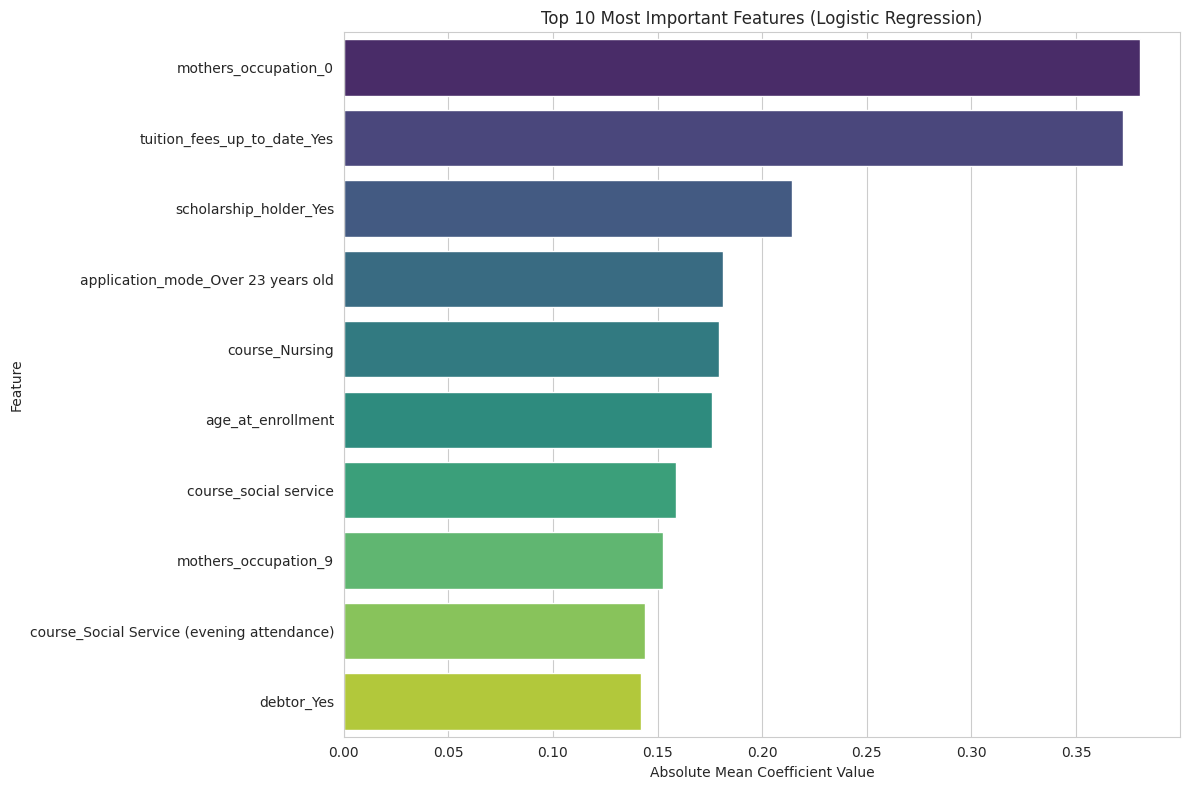

In [119]:
# Visualize the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(N), palette='viridis')
plt.title(f'Top {N} Most Important Features (Logistic Regression)')
plt.xlabel('Absolute Mean Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

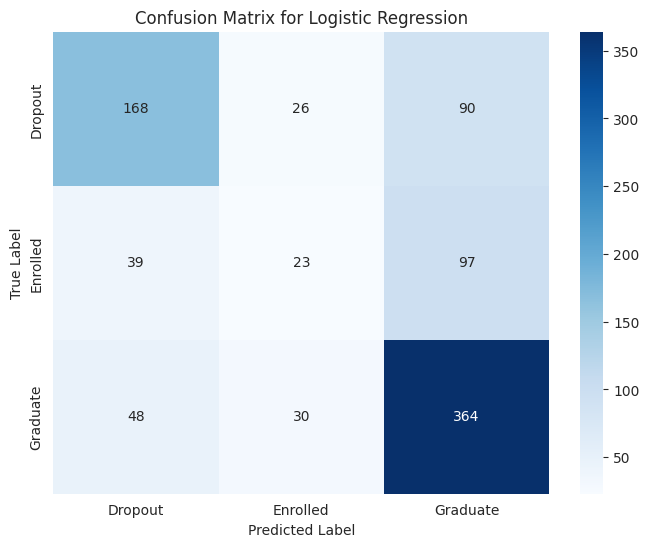

In [120]:
conf_matrix_lr = confusion_matrix(y_test_loaded, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [121]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, multi_class='multinomial', max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='balanced_accuracy', # Optimize for balanced accuracy due to potential class imbalance
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train_loaded, y_train_loaded)

print(f"Best parameters found for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best cross-validation balanced accuracy for Logistic Regression: {grid_search_lr.best_score_:.4f}")

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

print("Logistic Regression model retrained with best hyperparameters!")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Best cross-validation balanced accuracy for Logistic Regression: 0.5505
Logistic Regression model retrained with best hyperparameters!


### Individual Model ( Bernoulli Naive Bayes)

In [122]:
from sklearn.naive_bayes import BernoulliNB
bernoulli_nb_model = BernoulliNB()
bernoulli_nb_model.fit(X_train_loaded, y_train_loaded)
print("Bernoulli Naive Bayes model trained successfully using loaded data!")

Bernoulli Naive Bayes model trained successfully using loaded data!


In [123]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_bnb = bernoulli_nb_model.predict(X_test_loaded)

accuracy_bnb = accuracy_score(y_test_loaded, y_pred_bnb)
print(f"Bernoulli Naive Bayes Model Accuracy: {accuracy_bnb:.4f}")

target_names = ['Dropout', 'Enrolled', 'Graduate']
print("\nClassification Report (Bernoulli Naive Bayes):")
print(classification_report(y_test_loaded, y_pred_bnb, target_names=target_names))



Bernoulli Naive Bayes Model Accuracy: 0.5955

Classification Report (Bernoulli Naive Bayes):
              precision    recall  f1-score   support

     Dropout       0.58      0.62      0.60       284
    Enrolled       0.31      0.18      0.22       159
    Graduate       0.66      0.73      0.69       442

    accuracy                           0.60       885
   macro avg       0.51      0.51      0.51       885
weighted avg       0.57      0.60      0.58       885



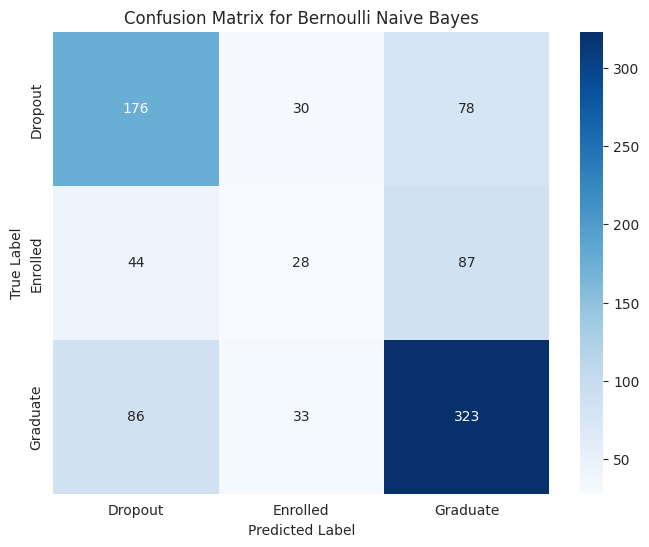

In [124]:
conf_matrix_bnb = confusion_matrix(y_test_loaded, y_pred_bnb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Bernoulli Naive Bayes')
plt.show()

Bernoulli Naive Bayes (Binarized Version)

In [125]:
X_train_binarized = X_train_loaded.copy()
X_test_binarized = X_test_loaded.copy()

numerical_cols = X_train_loaded.columns

for col in numerical_cols:
    median_val = X_train_loaded[col].median()
    X_train_binarized[col] = (X_train_binarized[col] > median_val).astype(int)
    X_test_binarized[col] = (X_test_binarized[col] > median_val).astype(int)

print("Features binarized successfully!")
print(f"X_train_binarized shape: {X_train_binarized.shape}")
print(f"X_test_binarized shape: {X_test_binarized.shape}")
display(X_train_binarized.head())

Features binarized successfully!
X_train_binarized shape: (3539, 71)
X_test_binarized shape: (885, 71)


,admission_grade,previous_qualification_grade,age_at_enrollment,tuition_fees_up_to_date_Yes,unemployment_rate,gdp,scholarship_holder_Yes,application_order,gender_Male,debtor_Yes,...,mothers_occupation_6,application_mode_3rd phase—general contingent,previous_qualification_Basic education 3rd cycle (9th/10th/11th year) or equiv.,mothers_qualification_Higher Education—bachelor’s degree,application_mode_Technological specialization diploma holders,mothers_occupation_1,course_Oral Hygiene,previous_qualification_Technological specialization course,application_mode_Holders of other higher courses,fathers_occupation_0
0,0,0,1,0,1,1,0,0,1,0,...,0,0,0,1,0,1,0,1,0,0
1,0,0,1,0,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
3,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Bernoulli Naive Bayes model trained successfully with binarized features!

Bernoulli Naive Bayes Model Accuracy (Binarized Features): 0.5819

Classification Report (Bernoulli Naive Bayes - Binarized Features):
              precision    recall  f1-score   support

     Dropout       0.54      0.62      0.57       284
    Enrolled       0.31      0.13      0.19       159
    Graduate       0.65      0.72      0.68       442

    accuracy                           0.58       885
   macro avg       0.50      0.49      0.48       885
weighted avg       0.55      0.58      0.56       885



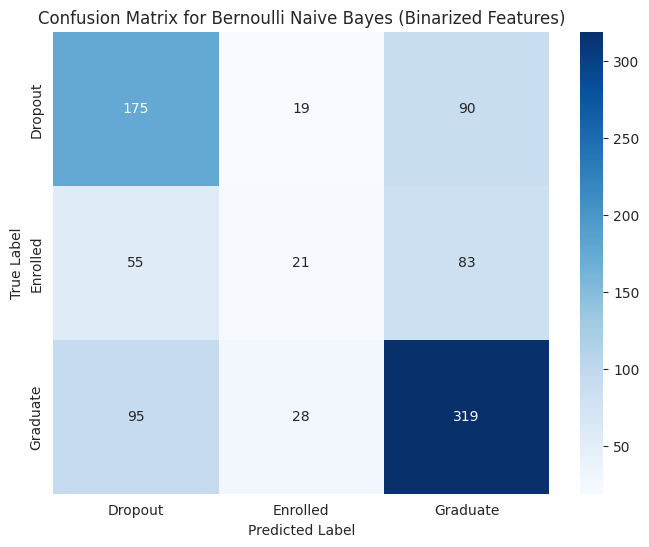

In [126]:

bernoulli_nb_model_binarized = BernoulliNB()

bernoulli_nb_model_binarized.fit(X_train_binarized, y_train_loaded)

print("Bernoulli Naive Bayes model trained successfully with binarized features!")

y_pred_bnb_binarized = bernoulli_nb_model_binarized.predict(X_test_binarized)

accuracy_bnb_binarized = accuracy_score(y_test_loaded, y_pred_bnb_binarized)
print(f"\nBernoulli Naive Bayes Model Accuracy (Binarized Features): {accuracy_bnb_binarized:.4f}")

target_names = ['Dropout', 'Enrolled', 'Graduate'] # Assuming these are consistent
print("\nClassification Report (Bernoulli Naive Bayes - Binarized Features):")
print(classification_report(y_test_loaded, y_pred_bnb_binarized, target_names=target_names))

conf_matrix_bnb_binarized = confusion_matrix(y_test_loaded, y_pred_bnb_binarized)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bnb_binarized, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Bernoulli Naive Bayes (Binarized Features)')
plt.show()

### Hyperparameter Tuning for Bernoulli Naive Bayes with GridSearchCV

In [127]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for alpha
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

grid_search_bnb = GridSearchCV(
    estimator=BernoulliNB(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_bnb.fit(X_train_binarized, y_train_loaded)

print(f"Best alpha found: {grid_search_bnb.best_params_['alpha']}")
print(f"Best cross-validation accuracy: {grid_search_bnb.best_score_:.4f}")

best_bnb_model = grid_search_bnb.best_estimator_

print("Bernoulli Naive Bayes model retrained with best alpha!")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best alpha found: 0.01
Best cross-validation accuracy: 0.5988
Bernoulli Naive Bayes model retrained with best alpha!


In [128]:
# Make predictions on the binarized test data using the best model
y_pred_bnb_tuned = best_bnb_model.predict(X_test_binarized)

# Evaluate the tuned model
accuracy_bnb_tuned = accuracy_score(y_test_loaded, y_pred_bnb_tuned)
print(f"\nBernoulli Naive Bayes Model Accuracy (Tuned Alpha, Binarized Features): {accuracy_bnb_tuned:.4f}")

# Classification Report
target_names = ['Dropout', 'Enrolled', 'Graduate'] # Assuming these are consistent
print("\nClassification Report (Bernoulli Naive Bayes - Tuned Alpha, Binarized Features):")
print(classification_report(y_test_loaded, y_pred_bnb_tuned, target_names=target_names))




Bernoulli Naive Bayes Model Accuracy (Tuned Alpha, Binarized Features): 0.5831

Classification Report (Bernoulli Naive Bayes - Tuned Alpha, Binarized Features):
              precision    recall  f1-score   support

     Dropout       0.54      0.61      0.57       284
    Enrolled       0.32      0.14      0.20       159
    Graduate       0.65      0.72      0.68       442

    accuracy                           0.58       885
   macro avg       0.50      0.49      0.49       885
weighted avg       0.56      0.58      0.56       885



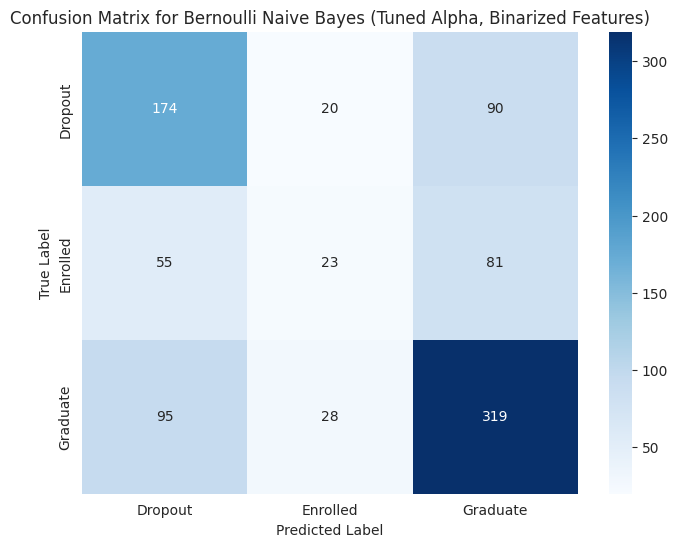

In [129]:
# Confusion Matrix
conf_matrix_bnb_tuned = confusion_matrix(y_test_loaded, y_pred_bnb_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bnb_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Bernoulli Naive Bayes (Tuned Alpha, Binarized Features)')
plt.show()

### Hyperparameter Tuning for Bernoulli Naive Bayes (Original Scaled Features)


In [130]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for alpha
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

grid_search_bnb_original = GridSearchCV(
    estimator=BernoulliNB(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_bnb_original.fit(X_train_loaded, y_train_loaded)

print(f"Best alpha found (original features): {grid_search_bnb_original.best_params_['alpha']}")
print(f"Best cross-validation accuracy (original features): {grid_search_bnb_original.best_score_:.4f}")

best_bnb_model_original = grid_search_bnb_original.best_estimator_

print("Bernoulli Naive Bayes model retrained with best alpha using original features!")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best alpha found (original features): 5.0
Best cross-validation accuracy (original features): 0.6146
Bernoulli Naive Bayes model retrained with best alpha using original features!


In [131]:
# Make predictions on the original scaled test data using the best model
y_pred_bnb_tuned_original = best_bnb_model_original.predict(X_test_loaded)

# Evaluate the tuned model
accuracy_bnb_tuned_original = accuracy_score(y_test_loaded, y_pred_bnb_tuned_original)
print(f"\nBernoulli Naive Bayes Model Accuracy (Tuned Alpha, Original Scaled Features): {accuracy_bnb_tuned_original:.4f}")

# Classification Report
target_names = ['Dropout', 'Enrolled', 'Graduate'] # Assuming these are consistent
print("\nClassification Report (Bernoulli Naive Bayes - Tuned Alpha, Original Scaled Features):")
print(classification_report(y_test_loaded, y_pred_bnb_tuned_original, target_names=target_names))




Bernoulli Naive Bayes Model Accuracy (Tuned Alpha, Original Scaled Features): 0.5955

Classification Report (Bernoulli Naive Bayes - Tuned Alpha, Original Scaled Features):
              precision    recall  f1-score   support

     Dropout       0.58      0.62      0.60       284
    Enrolled       0.31      0.17      0.22       159
    Graduate       0.66      0.73      0.69       442

    accuracy                           0.60       885
   macro avg       0.52      0.51      0.50       885
weighted avg       0.57      0.60      0.58       885



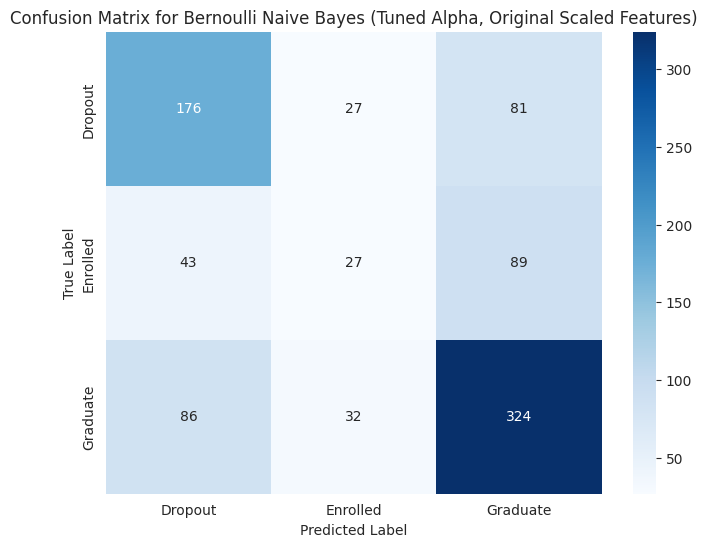

In [132]:
# Confusion Matrix
conf_matrix_bnb_tuned_original = confusion_matrix(y_test_loaded, y_pred_bnb_tuned_original)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bnb_tuned_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Bernoulli Naive Bayes (Tuned Alpha, Original Scaled Features)')
plt.show()

### Feature Influence Analysis for Bernoulli Naive Bayes



In [133]:

feature_names = X_train_loaded.columns
class_labels = best_bnb_model_original.classes_

feature_log_probs = best_bnb_model_original.feature_log_prob_
log_prob_df = pd.DataFrame(feature_log_probs, columns=feature_names, index=target_names)

log_prob_df = log_prob_df.T
log_prob_df['Range'] = log_prob_df.max(axis=1) - log_prob_df.min(axis=1)

log_prob_df = log_prob_df.sort_values(by='Range', ascending=False)

N = 10
print(f"Top {N} Most Discriminative Features for Bernoulli Naive Bayes (by log-prob range):")
display(log_prob_df.head(N))



Top 10 Most Discriminative Features for Bernoulli Naive Bayes (by log-prob range):


,Dropout,Enrolled,Graduate,Range
mothers_occupation_0,-2.590558,-4.859812,-3.819120,2.269255
course_Informatics Engineering,-2.754446,-2.408807,-4.649468,2.240661
mothers_qualification_Unknown,-2.602254,-4.523340,-4.048695,1.921086
fathers_occupation_0,-2.727417,-4.523340,-3.793802,1.795923
debtor_Yes,-1.507571,-2.165185,-3.151948,1.644378
application_mode_Holders of other higher courses,-2.754446,-4.071355,-3.793802,1.316909
fathers_qualification_Higher Education—bachelor’s degree,-4.000383,-3.173413,-4.486950,1.313536
scholarship_holder_Yes,-2.257413,-1.777902,-0.960589,1.296824
previous_qualification_Basic education 3rd cycle (9th/10th/11th year) or equiv.,-2.567568,-3.761200,-3.819120,1.251552
application_mode_Over 23 years old,-1.169974,-1.894539,-2.273196,1.103221


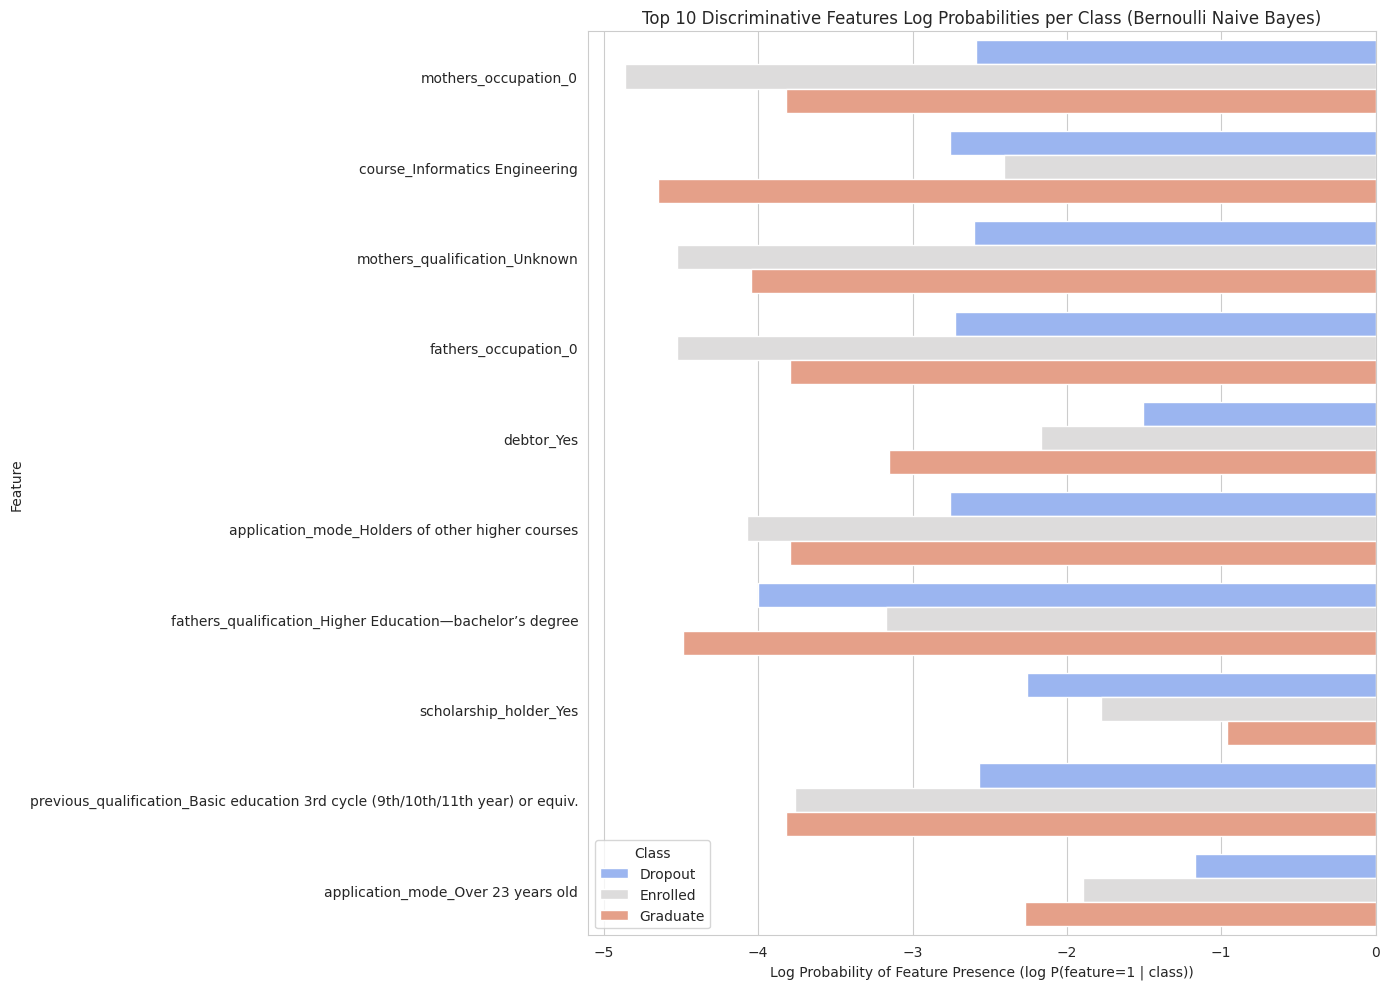

In [134]:
# Visualize the top N features' log probabilities for each class
plt.figure(figsize=(14, 10))
sns.barplot(x='value', y='Feature', hue='Class', data=log_prob_df.head(N).reset_index().melt(id_vars=['index', 'Range'], var_name='Class', value_name='value').rename(columns={'index': 'Feature'}), palette='coolwarm')
plt.title(f'Top {N} Discriminative Features Log Probabilities per Class (Bernoulli Naive Bayes)')
plt.xlabel('Log Probability of Feature Presence (log P(feature=1 | class))')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Comparing Top Features: Logistic Regression vs. Bernoulli Naive Bayes

In [135]:
N_comparison = 10
top_lr_features = feature_importance_df.head(N_comparison)[['Feature', 'Importance']].rename(columns={'Importance': 'LR_Importance'})
top_bnb_features = log_prob_df.head(N_comparison)[['Range']].reset_index().rename(columns={'index': 'Feature', 'Range': 'BNB_Discriminative_Power'})

comparison_df = pd.merge(top_lr_features, top_bnb_features, on='Feature', how='outer')

print(f"Top {N_comparison} Features Comparison:")
display(comparison_df.head(N_comparison*2))
common_features = pd.merge(top_lr_features, top_bnb_features, on='Feature', how='inner')
if not common_features.empty:
    print(f"\nCommon features among the top {N_comparison} for both models:")
    display(common_features)
else:
    print(f"\nNo common features found among the top {N_comparison} for both models.")

Top 10 Features Comparison:


,Feature,LR_Importance,BNB_Discriminative_Power
0,age_at_enrollment,0.176249,NaN
1,application_mode_Holders of other higher courses,NaN,1.316909
2,application_mode_Over 23 years old,0.181322,1.103221
3,course_Informatics Engineering,NaN,2.240661
4,course_Nursing,0.179218,NaN
5,course_Social Service (evening attendance),0.143984,NaN
6,course_social service,0.158753,NaN
7,debtor_Yes,0.142198,1.644378
8,fathers_occupation_0,NaN,1.795923
9,fathers_qualification_Higher Education—bachelo...,NaN,1.313536



Common features among the top 10 for both models:


,Feature,LR_Importance,BNB_Discriminative_Power
0,mothers_occupation_0,0.380685,2.269255
1,scholarship_holder_Yes,0.214239,1.296824
2,application_mode_Over 23 years old,0.181322,1.103221
3,debtor_Yes,0.142198,1.644378


### ROC Curve Comparison: Logistic Regression vs. Bernoulli Naive Bayes



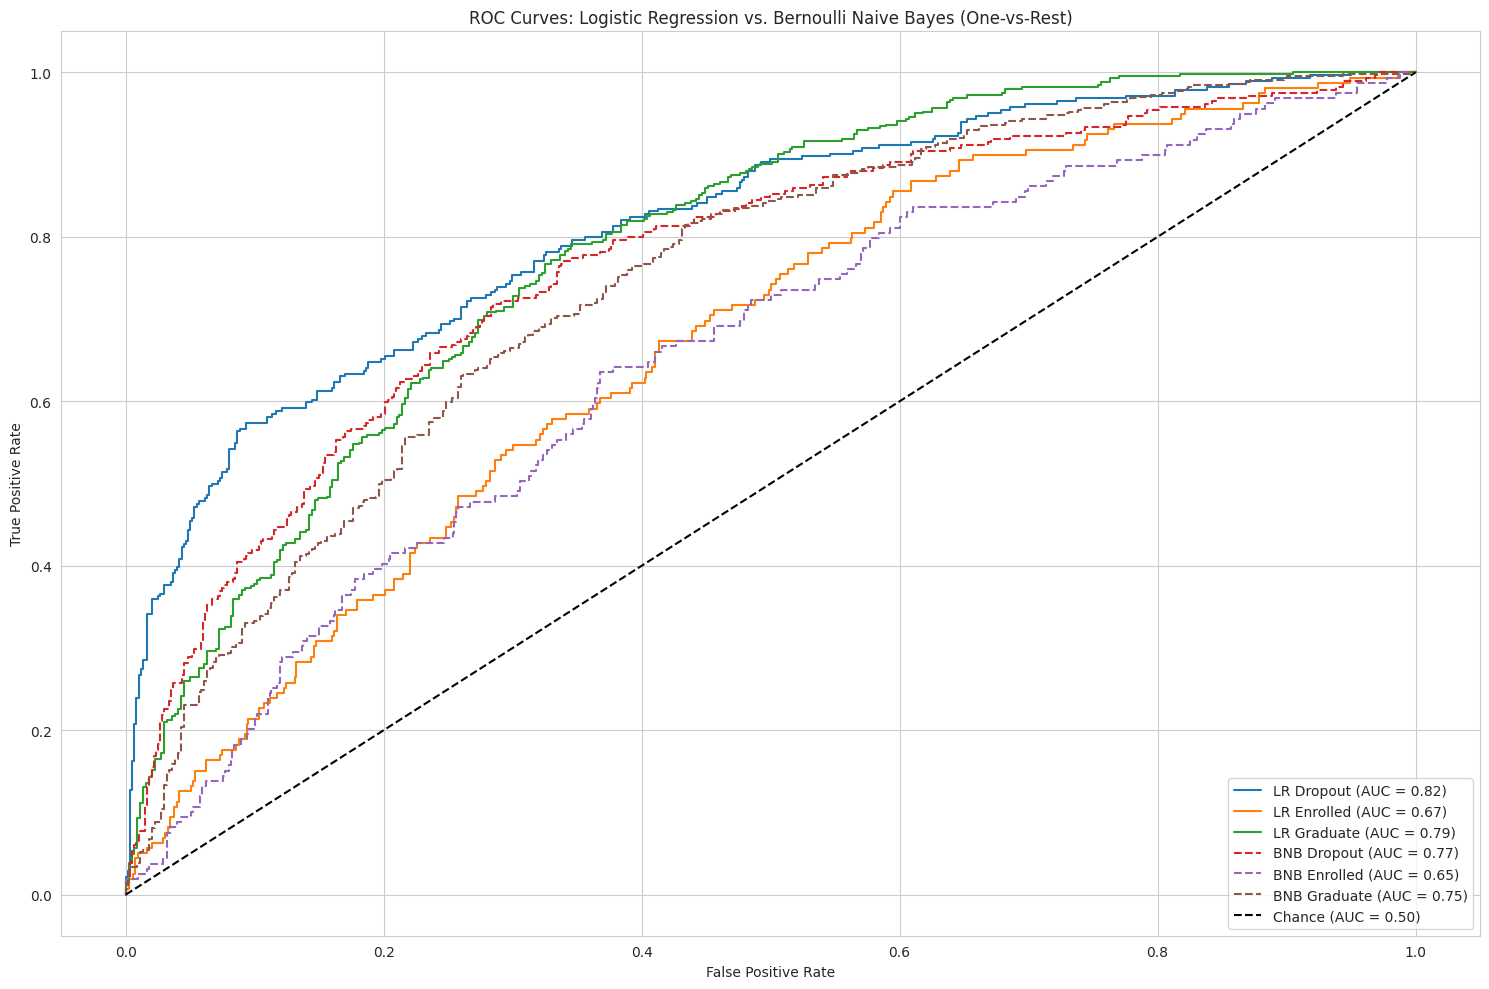

In [136]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test_loaded)
n_classes = y_test_binarized.shape[1]

plt.figure(figsize=(15, 10))

y_prob_lr = log_reg_model.predict_proba(X_test_loaded)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'LR {target_names[i]} (AUC = {roc_auc:.2f})', linestyle='-')

# ROC for Bernoulli Naive Bayes

y_prob_bnb = best_bnb_model_original.predict_proba(X_test_loaded)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob_bnb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'BNB {target_names[i]} (AUC = {roc_auc:.2f})', linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Logistic Regression vs. Bernoulli Naive Bayes (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

In [137]:
from sklearn.metrics import balanced_accuracy_score, classification_report

# --- Metrics for Logistic Regression ---
print("\n--- Logistic Regression Metrics ---")
y_pred_lr = log_reg_model.predict(X_test_loaded)

# Overall Accuracy (already calculated, but for completeness)
accuracy_lr = accuracy_score(y_test_loaded, y_pred_lr)
print(f"Overall Accuracy: {accuracy_lr:.4f}")

# Classification Report to extract macro and weighted averages
report_lr = classification_report(y_test_loaded, y_pred_lr, target_names=target_names, output_dict=True)

macro_accuracy_lr = report_lr['macro avg']['f1-score'] # F1-score is often used as a proxy for 'accuracy' in these averages
weighted_accuracy_lr = report_lr['weighted avg']['f1-score']
balanced_accuracy_lr = balanced_accuracy_score(y_test_loaded, y_pred_lr)

print(f"Macro F1-Score: {macro_accuracy_lr:.4f}")
print(f"Weighted F1-Score: {weighted_accuracy_lr:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_lr:.4f}")

# --- Metrics for Bernoulli Naive Bayes (tuned on original features) ---
print("\n--- Bernoulli Naive Bayes (Original Features, Tuned) Metrics ---")
y_pred_bnb_original = best_bnb_model_original.predict(X_test_loaded)

# Overall Accuracy (already calculated, but for completeness)
accuracy_bnb_original = accuracy_score(y_test_loaded, y_pred_bnb_original)
print(f"Overall Accuracy: {accuracy_bnb_original:.4f}")

# Classification Report to extract macro and weighted averages
report_bnb_original = classification_report(y_test_loaded, y_pred_bnb_original, target_names=target_names, output_dict=True)

macro_accuracy_bnb_original = report_bnb_original['macro avg']['f1-score']
weighted_accuracy_bnb_original = report_bnb_original['weighted avg']['f1-score']
balanced_accuracy_bnb_original = balanced_accuracy_score(y_test_loaded, y_pred_bnb_original)

print(f"Macro F1-Score: {macro_accuracy_bnb_original:.4f}")
print(f"Weighted F1-Score: {weighted_accuracy_bnb_original:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_bnb_original:.4f}")


--- Logistic Regression Metrics ---
Overall Accuracy: 0.6271
Macro F1-Score: 0.5166
Weighted F1-Score: 0.6009
Balanced Accuracy: 0.5199

--- Bernoulli Naive Bayes (Original Features, Tuned) Metrics ---
Overall Accuracy: 0.5955
Macro F1-Score: 0.5034
Weighted F1-Score: 0.5771
Balanced Accuracy: 0.5075


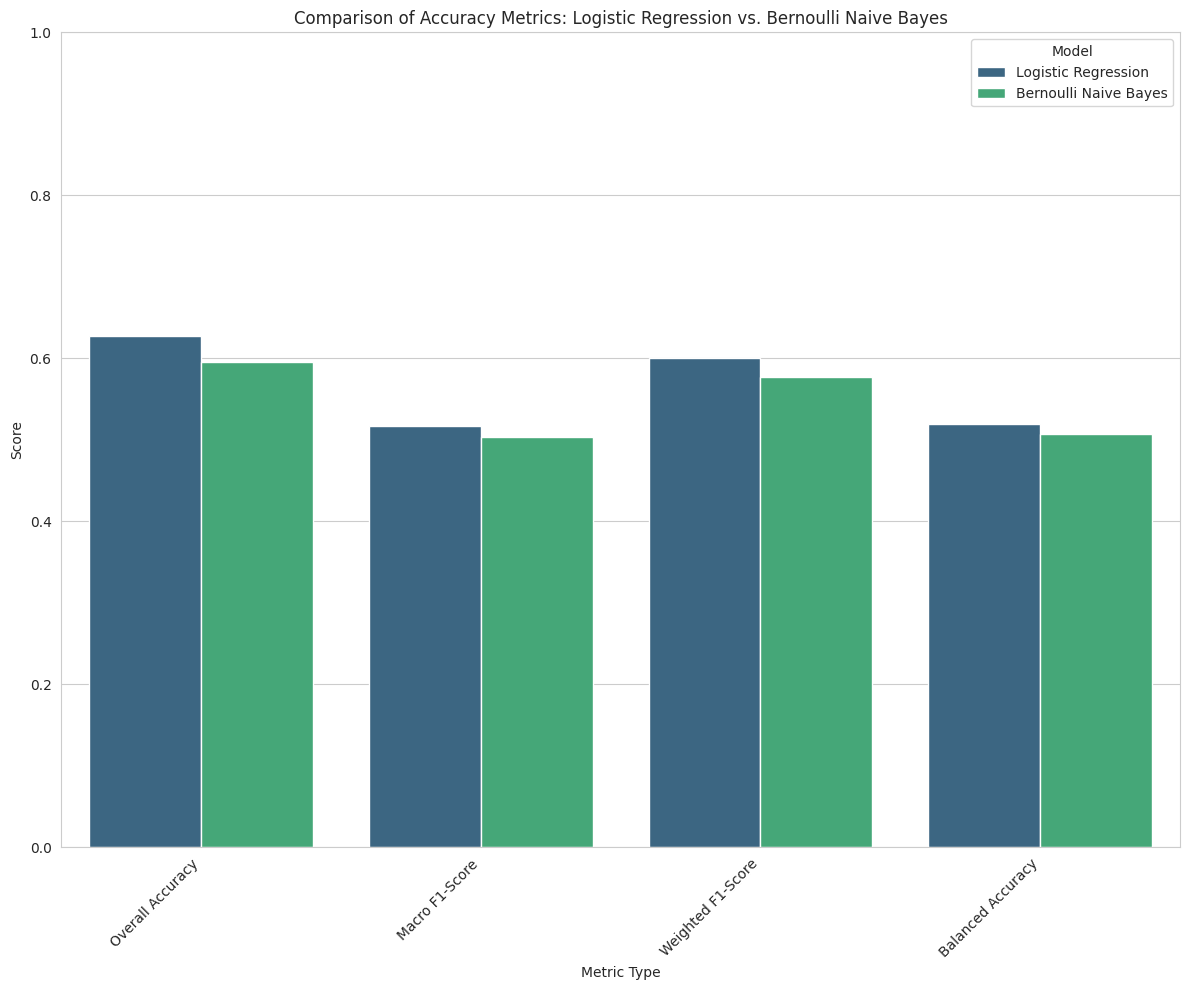

In [138]:

metrics_data = {
    'Model': [
        'Logistic Regression', 'Logistic Regression', 'Logistic Regression', 'Logistic Regression',
        'Bernoulli Naive Bayes', 'Bernoulli Naive Bayes', 'Bernoulli Naive Bayes', 'Bernoulli Naive Bayes'
    ],
    'Metric Type': [
        'Overall Accuracy', 'Macro F1-Score', 'Weighted F1-Score', 'Balanced Accuracy',
        'Overall Accuracy', 'Macro F1-Score', 'Weighted F1-Score', 'Balanced Accuracy'
    ],
    'Score': [
        accuracy_lr, macro_accuracy_lr, weighted_accuracy_lr, balanced_accuracy_lr,
        accuracy_bnb_original, macro_accuracy_bnb_original, weighted_accuracy_bnb_original, balanced_accuracy_bnb_original
    ]
}

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(12, 10))
sns.barplot(x='Metric Type', y='Score', hue='Model', data=metrics_df, palette='viridis')
plt.ylim(0, 1)
plt.title('Comparison of Accuracy Metrics: Logistic Regression vs. Bernoulli Naive Bayes')
plt.xlabel('Metric Type')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()



Analyzing misclassifications: True 'Enrolled' predicted as 'Graduate'


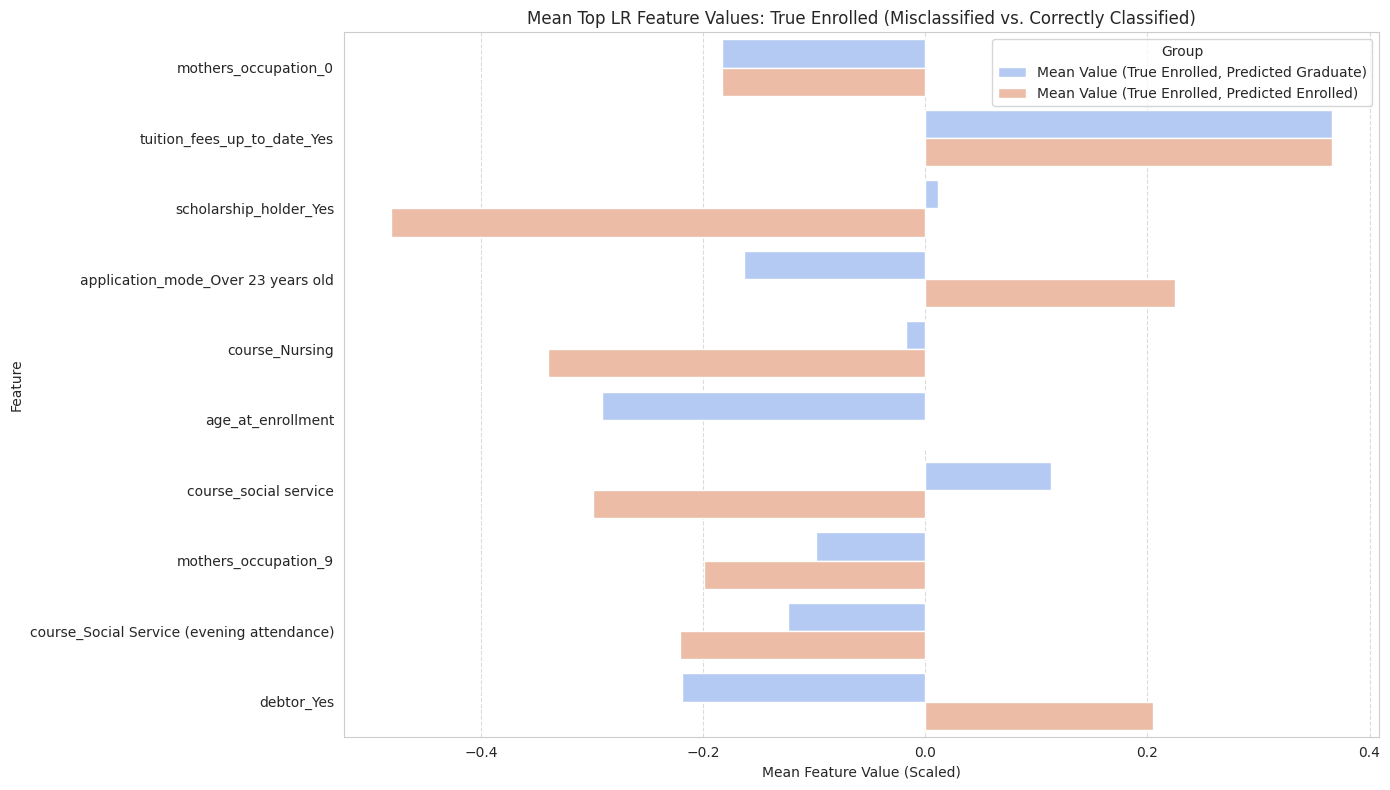

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare Data for Analysis ---
analysis_df = X_test_loaded.copy()
analysis_df['True Label'] = y_test_loaded
analysis_df['Predicted Label'] = y_pred_lr

# Map numerical labels to readable names
label_mapping = {idx: name for idx, name in enumerate(target_names)}
analysis_df['True Label Name'] = analysis_df['True Label'].map(label_mapping)
analysis_df['Predicted Label Name'] = analysis_df['Predicted Label'].map(label_mapping)

# Identify misclassified samples
misclassified_df = analysis_df[analysis_df['True Label'] != analysis_df['Predicted Label']].copy()

# --- Select Top N Logistic Regression Features ---
N_features_for_misclass_analysis = 10
top_lr_features_list = feature_importance_df.head(N_features_for_misclass_analysis)['Feature'].tolist()

# --- Analyze a specific misclassification type (e.g., True: Enrolled, Predicted: Graduate) ---
true_label_of_interest = 'Enrolled'
predicted_label_of_interest = 'Graduate'

# Misclassified samples for this specific error type
specific_misclassified_samples = misclassified_df[
    (misclassified_df['True Label Name'] == true_label_of_interest) &
    (misclassified_df['Predicted Label Name'] == predicted_label_of_interest)
]

# Correctly classified samples for the true label of interest
correctly_classified_samples = analysis_df[
    (analysis_df['True Label Name'] == true_label_of_interest) &
    (analysis_df['Predicted Label Name'] == true_label_of_interest)
]

if not specific_misclassified_samples.empty or not correctly_classified_samples.empty:
    print(f"\nAnalyzing misclassifications: True '{true_label_of_interest}' predicted as '{predicted_label_of_interest}'")

    # Calculate mean feature values for comparison
    misclassified_means = specific_misclassified_samples[top_lr_features_list].mean()
    correctly_classified_means = correctly_classified_samples[top_lr_features_list].mean()


    plot_data = pd.DataFrame({
        'Feature': top_lr_features_list,
        f'Mean Value (True {true_label_of_interest}, Predicted {predicted_label_of_interest})': misclassified_means.values,
        f'Mean Value (True {true_label_of_interest}, Predicted {true_label_of_interest})': correctly_classified_means.values
    })

    plot_data_melted = plot_data.melt(
        id_vars='Feature',
        var_name='Group',
        value_name='Mean Feature Value'
    )

    plt.figure(figsize=(14, 8))
    sns.barplot(x='Mean Feature Value', y='Feature', hue='Group', data=plot_data_melted, palette='coolwarm')
    plt.title(f'Mean Top LR Feature Values: True {true_label_of_interest} (Misclassified vs. Correctly Classified)')
    plt.xlabel('Mean Feature Value (Scaled)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"No samples found for analysis (True '{true_label_of_interest}', Predicted '{predicted_label_of_interest}' or Correctly Classified). Please adjust labels if needed.")


### Feature Analysis in Misclassified Samples (Logistic Regression): True Dropout, Predicted Enrolled



Analyzing misclassifications: True 'Dropout' predicted as 'Enrolled'


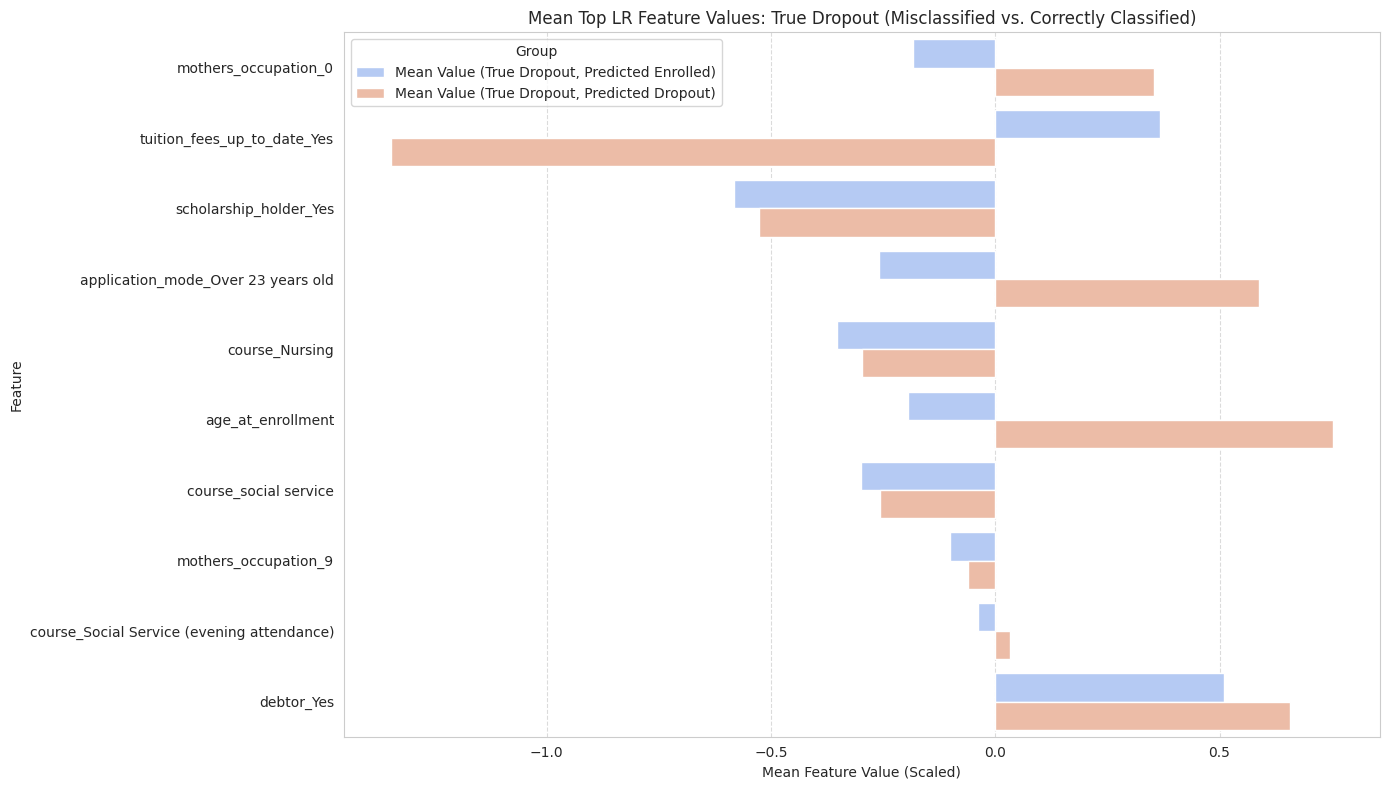

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

misclassified_df = analysis_df[analysis_df['True Label'] != analysis_df['Predicted Label']].copy()

# --- Select Top N Logistic Regression Features ---
N_features_for_misclass_analysis = 10
top_lr_features_list = feature_importance_df.head(N_features_for_misclass_analysis)['Feature'].tolist()

# --- Analyze a specific misclassification type (True: Dropout, Predicted: Enrolled) ---
true_label_of_interest = 'Dropout'
predicted_label_of_interest = 'Enrolled'

# Misclassified samples for this specific error type
specific_misclassified_samples = misclassified_df[
    (misclassified_df['True Label Name'] == true_label_of_interest) &
    (misclassified_df['Predicted Label Name'] == predicted_label_of_interest)
]

# Correctly classified samples for the true label of interest
correctly_classified_samples = analysis_df[
    (analysis_df['True Label Name'] == true_label_of_interest) &
    (analysis_df['Predicted Label Name'] == true_label_of_interest)
]

if not specific_misclassified_samples.empty or not correctly_classified_samples.empty:
    print(f"\nAnalyzing misclassifications: True '{true_label_of_interest}' predicted as '{predicted_label_of_interest}'")

    # Calculate mean feature values for comparison
    misclassified_means = specific_misclassified_samples[top_lr_features_list].mean()
    correctly_classified_means = correctly_classified_samples[top_lr_features_list].mean()

    # Combine into a single DataFrame for plotting
    plot_data = pd.DataFrame({
        'Feature': top_lr_features_list,
        f'Mean Value (True {true_label_of_interest}, Predicted {predicted_label_of_interest})': misclassified_means.values,
        f'Mean Value (True {true_label_of_interest}, Predicted {true_label_of_interest})': correctly_classified_means.values
    })

    plot_data_melted = plot_data.melt(
        id_vars='Feature',
        var_name='Group',
        value_name='Mean Feature Value'
    )

    plt.figure(figsize=(14, 8))
    sns.barplot(x='Mean Feature Value', y='Feature', hue='Group', data=plot_data_melted, palette='coolwarm')
    plt.title(f'Mean Top LR Feature Values: True {true_label_of_interest} (Misclassified vs. Correctly Classified)')
    plt.xlabel('Mean Feature Value (Scaled)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"No samples found for analysis (True '{true_label_of_interest}', Predicted '{predicted_label_of_interest}' or Correctly Classified). Please adjust labels if needed.")

###Saving Results

In [141]:

target_names = ['Dropout', 'Enrolled', 'Graduate']

y_pred_lr = log_reg_model.predict(X_test_loaded)
y_prob_lr = log_reg_model.predict_proba(X_test_loaded)

label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test_loaded)
lr_roc_auc = roc_auc_score(y_test_binarized, y_prob_lr, average='macro')

accuracy_lr = accuracy_score(y_test_loaded, y_pred_lr)
macro_f1_lr = f1_score(y_test_loaded, y_pred_lr, average='macro')
weighted_f1_lr = f1_score(y_test_loaded, y_pred_lr, average='weighted')
balanced_accuracy_lr = balanced_accuracy_score(y_test_loaded, y_pred_lr)
report_f1_lr_per_class = f1_score(y_test_loaded, y_pred_lr, average=None)

y_pred_bnb_original = best_bnb_model_original.predict(X_test_loaded)
y_prob_bnb_original = best_bnb_model_original.predict_proba(X_test_loaded)
bnb_roc_auc = roc_auc_score(y_test_binarized, y_prob_bnb_original, average='macro')

macro_f1_bnb_original = f1_score(y_test_loaded, y_pred_bnb_original, average='macro')
weighted_f1_bnb_original = f1_score(y_test_loaded, y_pred_bnb_original, average='weighted')
balanced_accuracy_bnb_original = balanced_accuracy_score(y_test_loaded, y_pred_bnb_original)
report_f1_bnb_per_class = f1_score(y_test_loaded, y_pred_bnb_original, average=None)

In [142]:

my_results = pd.DataFrame([
    {
        'member': 'Azad',
        'model': 'Logistic Regression',
        'model_type': 'shared',
        'best_params': str(log_reg_model.get_params()),
        'accuracy': accuracy_lr,
        'balanced_accuracy': balanced_accuracy_lr,
        'macro_f1': macro_f1_lr,
        'weighted_f1': weighted_f1_lr,
        'roc_auc': lr_roc_auc,
        'dropout_f1': report_f1_lr_per_class[0],
        'enrolled_f1': report_f1_lr_per_class[1],
        'graduate_f1': report_f1_lr_per_class[2],
    },
    {
        'member': 'Azad',
        'model': 'Bernoulli Naive Bayes',
        'model_type': 'unique',
        'best_params': str(best_bnb_model_original.get_params()),
        'accuracy': accuracy_bnb_original,
        'balanced_accuracy': balanced_accuracy_bnb_original,
        'macro_f1': macro_f1_bnb_original,
        'weighted_f1': weighted_f1_bnb_original,
        'roc_auc': bnb_roc_auc,
        'dropout_f1': report_f1_bnb_per_class[0],
        'enrolled_f1': report_f1_bnb_per_class[1],
        'graduate_f1': report_f1_bnb_per_class[2],
    },
])

results_path = os.path.join(RESULTS_DIR, 'results_azad.csv')
my_results.to_csv(results_path, index=False)

print(f'Saved to: {results_path}')
print(my_results[['member', 'model', 'balanced_accuracy', 'macro_f1', 'roc_auc']].to_string(index=False))

Saved to: /content/drive/MyDrive/COMM074_Project/results/results_azad.csv
member                 model  balanced_accuracy  macro_f1  roc_auc
  Azad   Logistic Regression           0.519911  0.516595 0.757510
  Azad Bernoulli Naive Bayes           0.507520  0.503446 0.722948
